In [50]:
import os
import cloudpickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

df = pd.read_csv('train.csv')
df_full = pd.read_excel('US_dataQ.xlsx')
cols = ['FEDFUNDS', 'DTWEXBGS', 'GDPC1', 'CPIAUCSL', 'RTWEXBGS']

def transform(frame):
    out = frame.assign(Date=pd.to_datetime(frame.Date)).set_index('Date')[cols].astype(float).sort_index()
    out['FEDFUNDS'] = out.FEDFUNDS.diff()
    out[cols[1:]] = np.log(out[cols[1:]]).diff()
    return out.dropna()

data, data_full = transform(df), transform(df_full)
train_end = data.index.max()


# Модели инфляции

Для каждого горизонта $h=1,\ldots,8$ строятся отдельные выборки для каждого типа residual FEDFUNDS. Базовые признаки — текущие значения и лаги 1–2 всех преобразованных рядов кроме FEDFUNDS. К ним добавляется прогноз соответствующей сохранённой формулы PySR.

В текущем наборе 22 типа residual ставки и 22 итоговых регрессора: 484 комбинации траекторий, каждая из которых содержит восемь горизонтальных моделей.


In [51]:
RATE_MODEL_DIR = Path('models/fedfunds')
PYSR_MODEL_DIR = Path('models/inflation_pysr')
INFL_MODEL_DIR = Path(os.getenv('INFL_MODEL_DIR', 'models/inflation_models'))
INFL_MODEL_DIR.mkdir(parents=True, exist_ok=True)

RATE_MODEL_NAMES = sorted(p.stem.rsplit('_fedfunds_h', 1)[0]
                          for p in RATE_MODEL_DIR.glob('*_fedfunds_h1.pkl')
                          if not p.stem.startswith('tuned_params_'))
RATE_LIMIT = int(os.getenv('INFL_RATE_LIMIT', 0)) or None
MODEL_LIMIT = int(os.getenv('INFL_MODEL_LIMIT', 0)) or None
ACTIVE_RATE_NAMES = RATE_MODEL_NAMES[:RATE_LIMIT] if RATE_LIMIT else RATE_MODEL_NAMES
REFIT_MODELS = os.getenv('REFIT_INFL_MODELS', '0') == '1'
SEED, N_TRIALS = 42, int(os.getenv('INFL_N_TRIALS', 10))

assert ACTIVE_RATE_NAMES and all((RATE_MODEL_DIR / f'{name}_fedfunds_h{h}.pkl').exists()
                                 for h in range(1, 9) for name in ACTIVE_RATE_NAMES)
assert all((PYSR_MODEL_DIR / f'pysr_cpiaucsl_h{h}_{name}_fedfunds.pkl').exists()
           for h in range(1, 9) for name in ACTIVE_RATE_NAMES)


## Residual FEDFUNDS и признаки PySR

Residual на дате $t$ — фактический уровень FEDFUNDS минус восстановленный прогноз уровня, сделанный $h$ кварталов ранее. Функция признаков полностью совпадает с rate_modls.ipynb.


In [52]:
def make_features(z, h):
    F1, F2, F3 = (z.FEDFUNDS.shift(i) for i in (1, 2, 3))
    D1, D2, D3 = (z.DTWEXBGS.shift(i) for i in (1, 2, 3))
    G1, G2, G3 = (z.GDPC1.shift(i) for i in (1, 2, 3))
    C1, C2, C3 = (z.CPIAUCSL.shift(i) for i in (1, 2, 3))
    R1, R2, R3 = (z.RTWEXBGS.shift(i) for i in (1, 2, 3))

    engineered = {
        1: lambda: [
            np.sin(F1 * (1.5105 - F3)),
            1.4905 * np.sin(F1 * (F3 - 1.0672)**2),
            1.545 * np.sin(F1 * (F3 + D2 - 1.0757)**2),
            1.6005 * np.sin(F1 * (F3 - 1.0543 - 3.8208 * D2 * F2)**2),
            (1.0085 + C1 / .02507) * np.sin(F1 * (1 + (F3 - .54019)**2 - F3)),
            (.99788 + C3 / .025327 - D2 / .081413) * np.sin(F1 * (1 + (F3 - .51752)**2 - F3))
        ],
        2: lambda: [
            6.0423 * R1 + np.sin(np.sin(F1)),
            np.sin(F1) + .4145 * np.sin(12.67 * F1) - G1 / .11288,
            .41701 * np.sin(12.597 * (F1 + G1)) + np.sin(F1) - G1 / .12789,
            np.sin(1.8377 * F1) + .39022 * np.sin(13.492 * (F1 + C3)) - .33503 * F3,
            .38827 * np.sin(13.486 * (F1 + C2 + C3)) - .33506 * F3 + np.sin(1.8505 * F1),
            .38932 * np.sin(13.194 * (F1 + 2.867 * C3)) + np.sin(1.7363 * F1) - .31582 * F3 - G1 / .12759
        ],
        3: lambda: [
            C1**2 * (C1 + R2),
            (174.68 * C1 - 2.6608 * F1)**2 * (R2 + C1),
            (R1 / R2 + 1.5141) * (R2 + C1) * (174.68 * C1 - 2.6608 * F1)**2,
            np.sin((22.525 * C1**2 / D2 + .28412)**2 - .11499 + F1 / 4.0387),
            1.4565 * np.sin((22.545 * C1**2 / D2 + .28325)**2 - .11479 + F1 / 3.9611 - C2),
            (1.631 + R1 / R2) * ((R2 + C1) * (174.68 * C1 - 2.6554 * F1)**2 - R2) - G1
        ],
        4: lambda: [
            22.8 * C1 * C2 / R1,
            np.sin(27.226 * C1 * C2 / R1),
            np.sin(16.841 * C1 * C2 * C3 / (D2 * R3)),
            (C1 / D2 - F1) * np.sin(20.196 * C3 * (C1 / R3 - .75193)),
            np.sin((R1 / R2 + 3.4861 * C1 / R1) * (595.71 * C1 * C2 + D1)),
            1.243 * np.sin(563.8 * C1 * C2 * (R1 / R2 + C1 * (3.2654 / R1 + 1.1972 / R2)))
        ],
        5: lambda: [
            np.sin(5923.5**2 * G3**2 * C1**2),
            np.sin((3.1106 * C1 / R3 - 1.695)**2 * (G3 + G2)),
            np.sin(((2.9252 * C1 / R3 - 1.7253)**2 - R1 / R2) * (G1 + G2)),
            1.5248 * np.sin(((2.9252 * C1 / R3 - 1.7253)**2 + C3 / (.61061 * R2)) * (G1 + G2)),
            1.3843 * np.sin(G2 / R2 * ((.60449 * C1 / D1)**2 - .065813)),
            (1.719 - F1**2) * np.sin(C1 / R2 * np.sin(.28364 * C1**2 / D1**2 - .049407))
        ],
        6: lambda: [
            (D1 / R1 - 1.2875)**2 * (50.549 * G3)**2,
            1.4863 * np.sin((52.583 * G3 * (D1 / R1 - 1.2993))**2),
            (15.327 * (R1 / D1 - .68966) * (R1 + 3.2356 * G3))**2 - .085454 * (R1 / D1)**2,
            (G1 + 2.4972 * C1) * (3.7732 + C2 / R1 - .021685 / R2) + G1,
            G1 * C1 / R1 * (5.0829 + C2 / R2) * (1.8381 - 3.0663 * C2 / D2),
            (4.9792 + C2 / R2) * (G1 + C1 / R1 * (R1 + G1 * (2.021 - 3.2115 * C2 / D2))) + G2
        ],
        7: lambda: [
            G2 / np.sin(4.4741 / C1),
            2.6389 * (C1 / np.sin(-.049636 / (R2 * G1)) + G2 / np.sin(3.7701 / C1) + C1 * C2 / R1),
            (G3 / .065448)**2 + G1 / .23016 - .0033526 * F3 / R1 + R3,
            (F3 * R2 / (28.84 * R1))**2 + (D3 + G3 * (F2 - .58751) / -.035273)**2,
            (F3 * R2 / (28.84 * R1))**2 + (2 * D3 + G3 * (F2 - .59881) / -.035622)**2 + G1 + R3,
            (F3 * R2 / (28.84 * R1))**2 + (G3 * (F2 - .59881) / -.035273 + G2 + 2 * D3)**2 + G1 + C1 + R3
        ],
        8: lambda: [
            (12.255 * (G1 - G3))**2,
            (G3 - G1)**2 * (R2 / C2 - 10.571)**2,
            (12.367 * (G1 - G3))**2 - (F3 * (F3 + 1.2667))**2,
            233.23 * G2**2 + G1 / D1 * (3.1726 * D2 + G1 * R1 / R2),
            (np.sin(F1) + G1 / D1) * (G1 * R1 / R2 + 3.3905 * D2) + 235.35 * G2**2 + R2,
            237.65 * G2**2 + 2 * R2 + G1 / D1 * (3.6347 * D2 + R1 * G1 / R2) - .20974 * np.sin(np.sin(F1))
        ]
    }
    X = z[cols].copy()
    for i, feature in enumerate(engineered[h](), 1):
        X[f'formula_{i}'] = feature
    return X.replace([np.inf, -np.inf], np.nan)


In [53]:
rate_features = {'train': {h: make_features(data, h) for h in range(1, 9)},
                 'full': {h: make_features(data_full, h) for h in range(1, 9)}}
rate_diffs = {'train': {}, 'full': {}}

for name in ACTIVE_RATE_NAMES:
    for h in range(1, 9):
        with (RATE_MODEL_DIR / f'{name}_fedfunds_h{h}.pkl').open('rb') as file:
            rate_model = cloudpickle.load(file)
        for sample_name, z in [('train', data), ('full', data_full)]:
            X = rate_features[sample_name][h]
            valid = X.dropna().index
            prediction = pd.Series(np.nan, index=z.index)
            prediction.loc[valid] = rate_model.predict(X.loc[valid])
            rate_diffs[sample_name][name, h] = prediction


def rate_residual(z, level, predictions, name, h):
    diffs = pd.concat([predictions[name, k] for k in range(1, h + 1)], axis=1).dropna()
    positions = z.index.get_indexer(diffs.index)
    diffs = diffs.iloc[positions + h < len(z)]
    positions = z.index.get_indexer(diffs.index)
    targets = z.index[positions + h]
    forecast = level.loc[diffs.index].to_numpy() + diffs.sum(axis=1).to_numpy()
    return pd.Series(level.loc[targets].to_numpy() - forecast, index=targets, name='FEDFUNDS_GAP')


levels = {
    'train': df.assign(Date=pd.to_datetime(df.Date)).set_index('Date').FEDFUNDS.astype(float),
    'full': df_full.assign(Date=pd.to_datetime(df_full.Date)).set_index('Date').FEDFUNDS.astype(float)
}
rate_residuals = {
    sample_name: {(h, name): rate_residual(z, levels[sample_name], rate_diffs[sample_name], name, h)
                  for h in range(1, 9) for name in ACTIVE_RATE_NAMES}
    for sample_name, z in [('train', data), ('full', data_full)]
}


In [54]:
def pysr_inputs(z, residual):
    source = z[['DTWEXBGS', 'GDPC1', 'RTWEXBGS']].copy()
    source['FEDFUNDS_GAP'] = residual
    return pd.DataFrame({
        f'{name}_t' if lag == 0 else f'{name}_lag{lag}': source[name].shift(lag)
        for name in source for lag in range(3)
    }).replace([np.inf, -np.inf], np.nan)


pysr_features = {'train': {}, 'full': {}}
for h in range(1, 9):
    for rate_name in ACTIVE_RATE_NAMES:
        with (PYSR_MODEL_DIR / f'pysr_cpiaucsl_h{h}_{rate_name}_fedfunds.pkl').open('rb') as file:
            pysr_model = cloudpickle.load(file)
        for sample_name, z in [('train', data), ('full', data_full)]:
            X = pysr_inputs(z, rate_residuals[sample_name][h, rate_name])
            valid = X.dropna().index
            feature = pd.Series(np.nan, index=z.index, name='PYSR_FEATURE')
            feature.loc[valid] = pysr_model.predict(X.loc[valid])
            pysr_features[sample_name][h, rate_name] = feature.replace([np.inf, -np.inf], np.nan)


## Выборки по горизонтам

X_h1, …, X_h8 — словари по типу residual ставки; например, X_h1['ard']. y_h1, …, y_h8 — будущие значения преобразованного CPIAUCSL.


In [55]:
BASE_FEATURES = ['DTWEXBGS', 'GDPC1', 'CPIAUCSL', 'RTWEXBGS']

def make_infl_X(z, h, rate_name, sample_name, training=True):
    X = pd.DataFrame({
        f'{name}_t' if lag == 0 else f'{name}_lag{lag}': z[name].shift(lag)
        for name in BASE_FEATURES for lag in range(3)
    })
    X['PYSR_FEATURE'] = pysr_features[sample_name][h, rate_name]
    if training: X = X.loc[z.CPIAUCSL.shift(-h).notna()]
    return X.replace([np.inf, -np.inf], np.nan).dropna()


def horizon_X(z, h, sample_name, training=True):
    return {name: make_infl_X(z, h, name, sample_name, training) for name in ACTIVE_RATE_NAMES}


y_h1, X_h1, X_full_h1 = data.CPIAUCSL.shift(-1).dropna().rename('y_h1'), horizon_X(data, 1, 'train'), horizon_X(data_full, 1, 'full', False)
y_h2, X_h2, X_full_h2 = data.CPIAUCSL.shift(-2).dropna().rename('y_h2'), horizon_X(data, 2, 'train'), horizon_X(data_full, 2, 'full', False)
y_h3, X_h3, X_full_h3 = data.CPIAUCSL.shift(-3).dropna().rename('y_h3'), horizon_X(data, 3, 'train'), horizon_X(data_full, 3, 'full', False)
y_h4, X_h4, X_full_h4 = data.CPIAUCSL.shift(-4).dropna().rename('y_h4'), horizon_X(data, 4, 'train'), horizon_X(data_full, 4, 'full', False)
y_h5, X_h5, X_full_h5 = data.CPIAUCSL.shift(-5).dropna().rename('y_h5'), horizon_X(data, 5, 'train'), horizon_X(data_full, 5, 'full', False)
y_h6, X_h6, X_full_h6 = data.CPIAUCSL.shift(-6).dropna().rename('y_h6'), horizon_X(data, 6, 'train'), horizon_X(data_full, 6, 'full', False)
y_h7, X_h7, X_full_h7 = data.CPIAUCSL.shift(-7).dropna().rename('y_h7'), horizon_X(data, 7, 'train'), horizon_X(data_full, 7, 'full', False)
y_h8, X_h8, X_full_h8 = data.CPIAUCSL.shift(-8).dropna().rename('y_h8'), horizon_X(data, 8, 'train'), horizon_X(data_full, 8, 'full', False)

pd.DataFrame({f'h{h}': [min(len(X) for X in globals()[f'X_h{h}'].values()), 13]
              for h in range(1, 9)}, index=['min observations', 'features'])


,h1,h2,h3,h4,h5,h6,h7,h8
min observations,65,63,61,59,57,55,53,51
features,13,13,13,13,13,13,13,13


## Модели и временная валидация

Optuna используется только для регуляризованных, робастной Huber и kernel-моделей; критерий выбора — MSE на последних 20% train, отделённых от train на h кварталов. Все древесные семейства имеют по две фиксированные неглубокие версии без тюнинга. После первого обучения каждый объект сохраняется с infl в имени и при следующих запусках загружается без фита. PySR-признак на train является in-sample; строгая оценка внутренней validation потребует отдельного time-series cross-fitting PySR. Финальный `df_full` при этом нигде не используется для обучения.


In [56]:
import optuna
import statsmodels.api as sm
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import (Ridge, Lasso, ElasticNet, HuberRegressor, RANSACRegressor,
                                  LinearRegression, BayesianRidge, ARDRegression)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.kernel_ridge import KernelRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)


In [57]:
class GLSARRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, rho=1): self.rho = rho
    def fit(self, X, y):
        self.scaler_ = StandardScaler().fit(X)
        exog = sm.add_constant(self.scaler_.transform(X), has_constant='add')
        self.model_ = sm.GLSAR(np.asarray(y), exog, rho=self.rho)
        self.result_ = self.model_.iterative_fit(maxiter=10)
        return self
    def predict(self, X):
        return np.asarray(self.result_.predict(sm.add_constant(self.scaler_.transform(X), has_constant='add')))


def scaled(model): return make_pipeline(StandardScaler(), model)


def make_model(name, p=None):
    p = p or {}
    makers = {
        'ridge': lambda: scaled(Ridge(alpha=p.get('alpha', 1.))),
        'lasso': lambda: scaled(Lasso(alpha=p.get('alpha', .01), max_iter=10000)),
        'elastic_net': lambda: scaled(ElasticNet(alpha=p.get('alpha', .01), l1_ratio=p.get('l1_ratio', .5), max_iter=10000)),
        'huber': lambda: scaled(HuberRegressor(epsilon=p.get('epsilon', 1.35), alpha=p.get('alpha', 1e-4), max_iter=2000)),
        'ransac': lambda: scaled(RANSACRegressor(LinearRegression(), min_samples=.7, loss='squared_error', max_trials=200, random_state=SEED)),
        'bayesian_ridge': lambda: scaled(BayesianRidge()),
        'ard': lambda: scaled(ARDRegression(max_iter=1000)),
        'glsar': GLSARRegressor,
        'decision_tree': lambda: DecisionTreeRegressor(max_depth=2, min_samples_split=12, min_samples_leaf=6, random_state=SEED),
        'decision_tree_v2': lambda: DecisionTreeRegressor(max_depth=3, min_samples_split=8, min_samples_leaf=4, random_state=SEED),
        'random_forest': lambda: RandomForestRegressor(n_estimators=200, max_depth=2, min_samples_leaf=5, max_features=.7, random_state=SEED, n_jobs=-1),
        'random_forest_v2': lambda: RandomForestRegressor(n_estimators=200, max_depth=3, min_samples_leaf=3, max_features=1., random_state=SEED, n_jobs=-1),
        'xgboost': lambda: XGBRegressor(n_estimators=250, max_depth=1, learning_rate=.02, min_child_weight=3, subsample=.9, reg_lambda=10, objective='reg:squarederror', random_state=SEED, n_jobs=1),
        'xgboost_v2': lambda: XGBRegressor(n_estimators=180, max_depth=2, learning_rate=.03, min_child_weight=4, subsample=.8, colsample_bytree=.8, reg_lambda=5, objective='reg:squarederror', random_state=SEED, n_jobs=1),
        'catboost': lambda: CatBoostRegressor(iterations=300, depth=2, learning_rate=.02, l2_leaf_reg=10, loss_function='RMSE', verbose=False, allow_writing_files=False, random_seed=SEED, thread_count=1),
        'catboost_v2': lambda: CatBoostRegressor(iterations=200, depth=3, learning_rate=.03, l2_leaf_reg=5, loss_function='RMSE', verbose=False, allow_writing_files=False, random_seed=SEED, thread_count=1),
        'lgbm': lambda: LGBMRegressor(n_estimators=250, num_leaves=3, max_depth=2, learning_rate=.02, min_child_samples=5, reg_lambda=10, verbosity=-1, random_state=SEED, n_jobs=1),
        'lgbm_v2': lambda: LGBMRegressor(n_estimators=180, num_leaves=5, max_depth=3, learning_rate=.03, min_child_samples=8, reg_lambda=5, verbosity=-1, random_state=SEED, n_jobs=1),
        'svr': lambda: scaled(SVR(C=p.get('C', 1.), epsilon=p.get('epsilon', .1), gamma=p.get('gamma', 'scale'))),
        'kernel_ridge': lambda: scaled(KernelRidge(alpha=p.get('alpha', 1.), kernel='rbf', gamma=p.get('gamma', .1))),
        'knn': lambda: scaled(KNeighborsRegressor(n_neighbors=p.get('n_neighbors', 5), weights=p.get('weights', 'distance'), p=p.get('p', 2))),
        'gaussian_process': lambda: scaled(GaussianProcessRegressor(
            kernel=ConstantKernel(1., constant_value_bounds='fixed') * RBF(p.get('length_scale', 1.), length_scale_bounds='fixed'),
            alpha=p.get('alpha', 1e-3), optimizer=None, normalize_y=True, random_state=SEED))
    }
    return makers[name]()


INFL_MODEL_NAMES = ['ridge', 'lasso', 'elastic_net', 'huber', 'ransac', 'bayesian_ridge', 'ard', 'glsar',
                    'decision_tree', 'decision_tree_v2', 'random_forest', 'random_forest_v2',
                    'xgboost', 'xgboost_v2', 'catboost', 'catboost_v2', 'lgbm', 'lgbm_v2',
                    'svr', 'kernel_ridge', 'knn', 'gaussian_process']
INFL_MODEL_NAMES = INFL_MODEL_NAMES[:MODEL_LIMIT] if MODEL_LIMIT else INFL_MODEL_NAMES
TUNED_NAMES = {'ridge', 'lasso', 'elastic_net', 'huber', 'svr', 'kernel_ridge', 'knn', 'gaussian_process'}


def tune_model(name, X, y, h):
    cut = int(.8 * len(X))
    Xt, Xv, yt, yv = X.iloc[:cut-h], X.iloc[cut:], y.iloc[:cut-h], y.iloc[cut:]
    def objective(trial):
        if name in {'ridge', 'lasso'}:
            p = {'alpha': trial.suggest_float('alpha', 1e-5, 1e3 if name == 'ridge' else 1., log=True)}
        elif name == 'elastic_net':
            p = {'alpha': trial.suggest_float('alpha', 1e-5, 1., log=True), 'l1_ratio': trial.suggest_float('l1_ratio', .1, .9)}
        elif name == 'huber':
            p = {'epsilon': trial.suggest_float('epsilon', 1.1, 2.), 'alpha': trial.suggest_float('alpha', 1e-6, 1e-1, log=True)}
        elif name == 'svr':
            p = {'C': trial.suggest_float('C', 1e-2, 100, log=True), 'epsilon': trial.suggest_float('epsilon', .005, .5, log=True), 'gamma': trial.suggest_float('gamma', 1e-3, 1., log=True)}
        elif name == 'kernel_ridge':
            p = {'alpha': trial.suggest_float('alpha', 1e-4, 10, log=True), 'gamma': trial.suggest_float('gamma', 1e-3, 1., log=True)}
        elif name == 'knn':
            p = {'n_neighbors': trial.suggest_int('n_neighbors', 2, min(15, len(Xt) - 1)), 'weights': trial.suggest_categorical('weights', ['uniform', 'distance']), 'p': trial.suggest_int('p', 1, 2)}
        else:
            p = {'length_scale': trial.suggest_float('length_scale', .1, 10, log=True), 'alpha': trial.suggest_float('alpha', 1e-6, .1, log=True)}
        model = make_model(name, p).fit(Xt, yt)
        return mean_squared_error(yv, model.predict(Xv))
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    return study.best_params


def model_path(model_name, rate_name, h):
    return INFL_MODEL_DIR / f'{model_name}_infl_{rate_name}_h{h}.pkl'


def load_model(model_name, rate_name, h):
    with model_path(model_name, rate_name, h).open('rb') as file: return cloudpickle.load(file)


In [58]:
def fit_horizon(h, X_by_rate, y):
    fitted_h = {}
    for rate_name, X in X_by_rate.items():
        params_path = INFL_MODEL_DIR / f'tuned_params_infl_{rate_name}_h{h}.pkl'
        complete = params_path.exists() and all(model_path(name, rate_name, h).exists() for name in INFL_MODEL_NAMES)
        if complete and not REFIT_MODELS:
            fitted = {name: load_model(name, rate_name, h) for name in INFL_MODEL_NAMES}
            assert all(not hasattr(model, 'feature_names_in_') or list(model.feature_names_in_) == X.columns.tolist()
                       for model in fitted.values()), 'Схема X изменилась: задайте REFIT_INFL_MODELS=1'
        else:
            target, best, fitted = y.loc[X.index], {}, {}
            for name in INFL_MODEL_NAMES:
                best[name] = tune_model(name, X, target, h) if name in TUNED_NAMES else {}
                fitted[name] = make_model(name, best[name]).fit(X, target)
                with model_path(name, rate_name, h).open('wb') as file: cloudpickle.dump(fitted[name], file)
            with params_path.open('wb') as file: cloudpickle.dump(best, file)
        for name, model in fitted.items(): globals()[f'{name}_{rate_name}_h{h}'] = model
        fitted_h[rate_name] = fitted
    for name in INFL_MODEL_NAMES:
        globals()[f'{name}_h{h}'] = {rate: fitted_h[rate][name] for rate in ACTIVE_RATE_NAMES}
    return fitted_h


## Горизонт 1


In [59]:
models_h1 = fit_horizon(1, X_h1, y_h1)
print(f'h1: {len(ACTIVE_RATE_NAMES)} residual-моделей × {len(INFL_MODEL_NAMES)} регрессоров')


h1: 22 residual-моделей × 22 регрессоров


## Горизонт 2


In [60]:
models_h2 = fit_horizon(2, X_h2, y_h2)
print(f'h2: {len(ACTIVE_RATE_NAMES)} residual-моделей × {len(INFL_MODEL_NAMES)} регрессоров')


h2: 22 residual-моделей × 22 регрессоров


## Горизонт 3


In [61]:
models_h3 = fit_horizon(3, X_h3, y_h3)
print(f'h3: {len(ACTIVE_RATE_NAMES)} residual-моделей × {len(INFL_MODEL_NAMES)} регрессоров')


h3: 22 residual-моделей × 22 регрессоров


## Горизонт 4


In [62]:
models_h4 = fit_horizon(4, X_h4, y_h4)
print(f'h4: {len(ACTIVE_RATE_NAMES)} residual-моделей × {len(INFL_MODEL_NAMES)} регрессоров')


h4: 22 residual-моделей × 22 регрессоров


## Горизонт 5


In [63]:
models_h5 = fit_horizon(5, X_h5, y_h5)
print(f'h5: {len(ACTIVE_RATE_NAMES)} residual-моделей × {len(INFL_MODEL_NAMES)} регрессоров')


h5: 22 residual-моделей × 22 регрессоров


## Горизонт 6


In [64]:
models_h6 = fit_horizon(6, X_h6, y_h6)
print(f'h6: {len(ACTIVE_RATE_NAMES)} residual-моделей × {len(INFL_MODEL_NAMES)} регрессоров')


h6: 22 residual-моделей × 22 регрессоров


## Горизонт 7


In [65]:
models_h7 = fit_horizon(7, X_h7, y_h7)
print(f'h7: {len(ACTIVE_RATE_NAMES)} residual-моделей × {len(INFL_MODEL_NAMES)} регрессоров')


h7: 22 residual-моделей × 22 регрессоров


## Горизонт 8


In [66]:
models_h8 = fit_horizon(8, X_h8, y_h8)
print(f'h8: {len(ACTIVE_RATE_NAMES)} residual-моделей × {len(INFL_MODEL_NAMES)} регрессоров')


h8: 22 residual-моделей × 22 регрессоров


## Фиксированный OOF

Модели не дообучаются после train. oof_mse измеряет MSE преобразованного CPIAUCSL. Дополнительно oof_mse_level оценивает восстановленный уровень индекса: прогнозируемые лог-разности горизонтов 1…h накапливаются от фактического уровня CPIAUCSL в origin.


In [67]:
models_by_h = {h: globals()[f'models_h{h}'] for h in range(1, 9)}
X_full_by_h = {h: globals()[f'X_full_h{h}'] for h in range(1, 9)}
cpi_level = df_full.assign(Date=pd.to_datetime(df_full.Date)).set_index('Date').CPIAUCSL.astype(float)
records = []

for origin in data_full.index[data_full.index >= train_end]:
    position = data_full.index.get_loc(origin)
    max_h = min(8, len(data_full) - position - 1)
    for rate_name in ACTIVE_RATE_NAMES:
        running_log = dict.fromkeys(INFL_MODEL_NAMES, np.log(cpi_level.loc[origin]))
        for h in range(1, max_h + 1):
            target_date, X = data_full.index[position + h], X_full_by_h[h][rate_name]
            if origin not in X.index: break
            for model_name in INFL_MODEL_NAMES:
                pred = models_by_h[h][rate_name][model_name].predict(X.loc[[origin]])[0]
                running_log[model_name] += pred
                records.append({'origin': origin, 'Date': target_date, 'horizon': h,
                                'rate_model': rate_name, 'infl_model': model_name,
                                'y_true': data_full.loc[target_date, 'CPIAUCSL'], 'y_pred': pred,
                                'level_true': cpi_level.loc[target_date], 'level_pred': np.exp(running_log[model_name])})

oof_predictions = pd.DataFrame(records)
oof_predictions['sq_error'] = (oof_predictions.y_true - oof_predictions.y_pred)**2
oof_predictions['sq_error_level'] = (oof_predictions.level_true - oof_predictions.level_pred)**2
oof_mse = oof_predictions.groupby(['horizon', 'rate_model', 'infl_model']).sq_error.mean().unstack('infl_model')
oof_mse_level = oof_predictions.groupby(['horizon', 'rate_model', 'infl_model']).sq_error_level.mean().unstack('infl_model')
oof_counts = oof_predictions.groupby('horizon').Date.nunique()
oof_mse.round(6)


infl_model                   ard  bayesian_ridge  catboost  catboost_v2  \
horizon rate_model                                                        
1       ard             0.000012        0.000015  0.000013     0.000014   
        bayesian_ridge  0.000012        0.000010  0.000011     0.000012   
        catboost        0.000012        0.000036  0.000014     0.000015   
        catboost_v2     0.000012        0.014360  0.000019     0.000022   
        decision_tree   0.000012        0.000016  0.000013     0.000014   
...                          ...             ...       ...          ...   
8       ransac          0.000036        0.000000  0.000003     0.000002   
        ridge           0.000036        0.000069  0.000006     0.000005   
        svr             0.000036        0.000031  0.000038     0.000042   
        xgboost         0.000036        0.000045  0.000055     0.000072   
        xgboost_v2      0.000036        0.000031  0.000038     0.000043   

infl_model              decision_tree  decision_tree_v2  elastic_net  \
horizon rate_model                                                     
1       ard                  0.000071          0.000024     0.000017   
        bayesian_ridge       0.000019          0.000012     0.000008   
        catboost             0.000071          0.000024     0.000040   
        catboost_v2          0.000071          0.000024     0.012455   
        decision_tree        0.000071          0.000024     0.000017   
...                               ...               ...          ...   
8       ransac               0.000005          0.000015     0.000002   
        ridge                0.000014          0.000018     0.000068   
        svr                  0.000032          0.000018     0.000035   
        xgboost              0.000065          0.000093     0.000036   
        xgboost_v2           0.000009          0.000071     0.000032   

infl_model              gaussian_process     glsar     huber  ...     lasso  \
horizon rate_model                                            ...             
1       ard                     0.000015  0.000024  0.000019  ...  0.000017   
        bayesian_ridge          0.000012  0.000012  0.000012  ...  0.000008   
        catboost                0.000012  0.000059  0.000058  ...  0.000037   
        catboost_v2             0.000012  0.021483  0.022439  ...  0.011390   
        decision_tree           0.000015  0.000028  0.000011  ...  0.000016   
...                                  ...       ...       ...  ...       ...   
8       ransac                  0.000001  0.000002  0.000002  ...  0.000002   
        ridge                   0.000002  0.000142  0.000105  ...  0.000062   
        svr                     0.000067  0.000032  0.000038  ...  0.000035   
        xgboost                 0.000036  0.000054  0.000059  ...  0.000036   
        xgboost_v2              0.000111  0.000045  0.000036  ...  0.000032   

infl_model                  lgbm   lgbm_v2  random_forest  random_forest_v2  \
horizon rate_model                                                            
1       ard             0.000012  0.000021       0.000014          0.000015   
        bayesian_ridge  0.000015  0.000022       0.000013          0.000013   
        catboost        0.000016  0.000029       0.000015          0.000017   
        catboost_v2     0.000017  0.000028       0.000014          0.000015   
        decision_tree   0.000018  0.000026       0.000014          0.000016   
...                          ...       ...            ...               ...   
8       ransac          0.000001  0.000003       0.000003          0.000008   
        ridge           0.000004  0.000009       0.000005          0.000010   
        svr             0.000045  0.000046       0.000035          0.000039   
        xgboost         0.000061  0.000053       0.000050          0.000061   
        xgboost_v2      0.000040  0.000006       0.000022          0.000030   

infl_model                ransa

## Траектории прогнозов и факт

Одна панель соответствует типу итоговой модели инфляции, цвет линии — тип residual FEDFUNDS/PySR. На графике показан восстановленный уровень CPIAUCSL из общей точки origin.


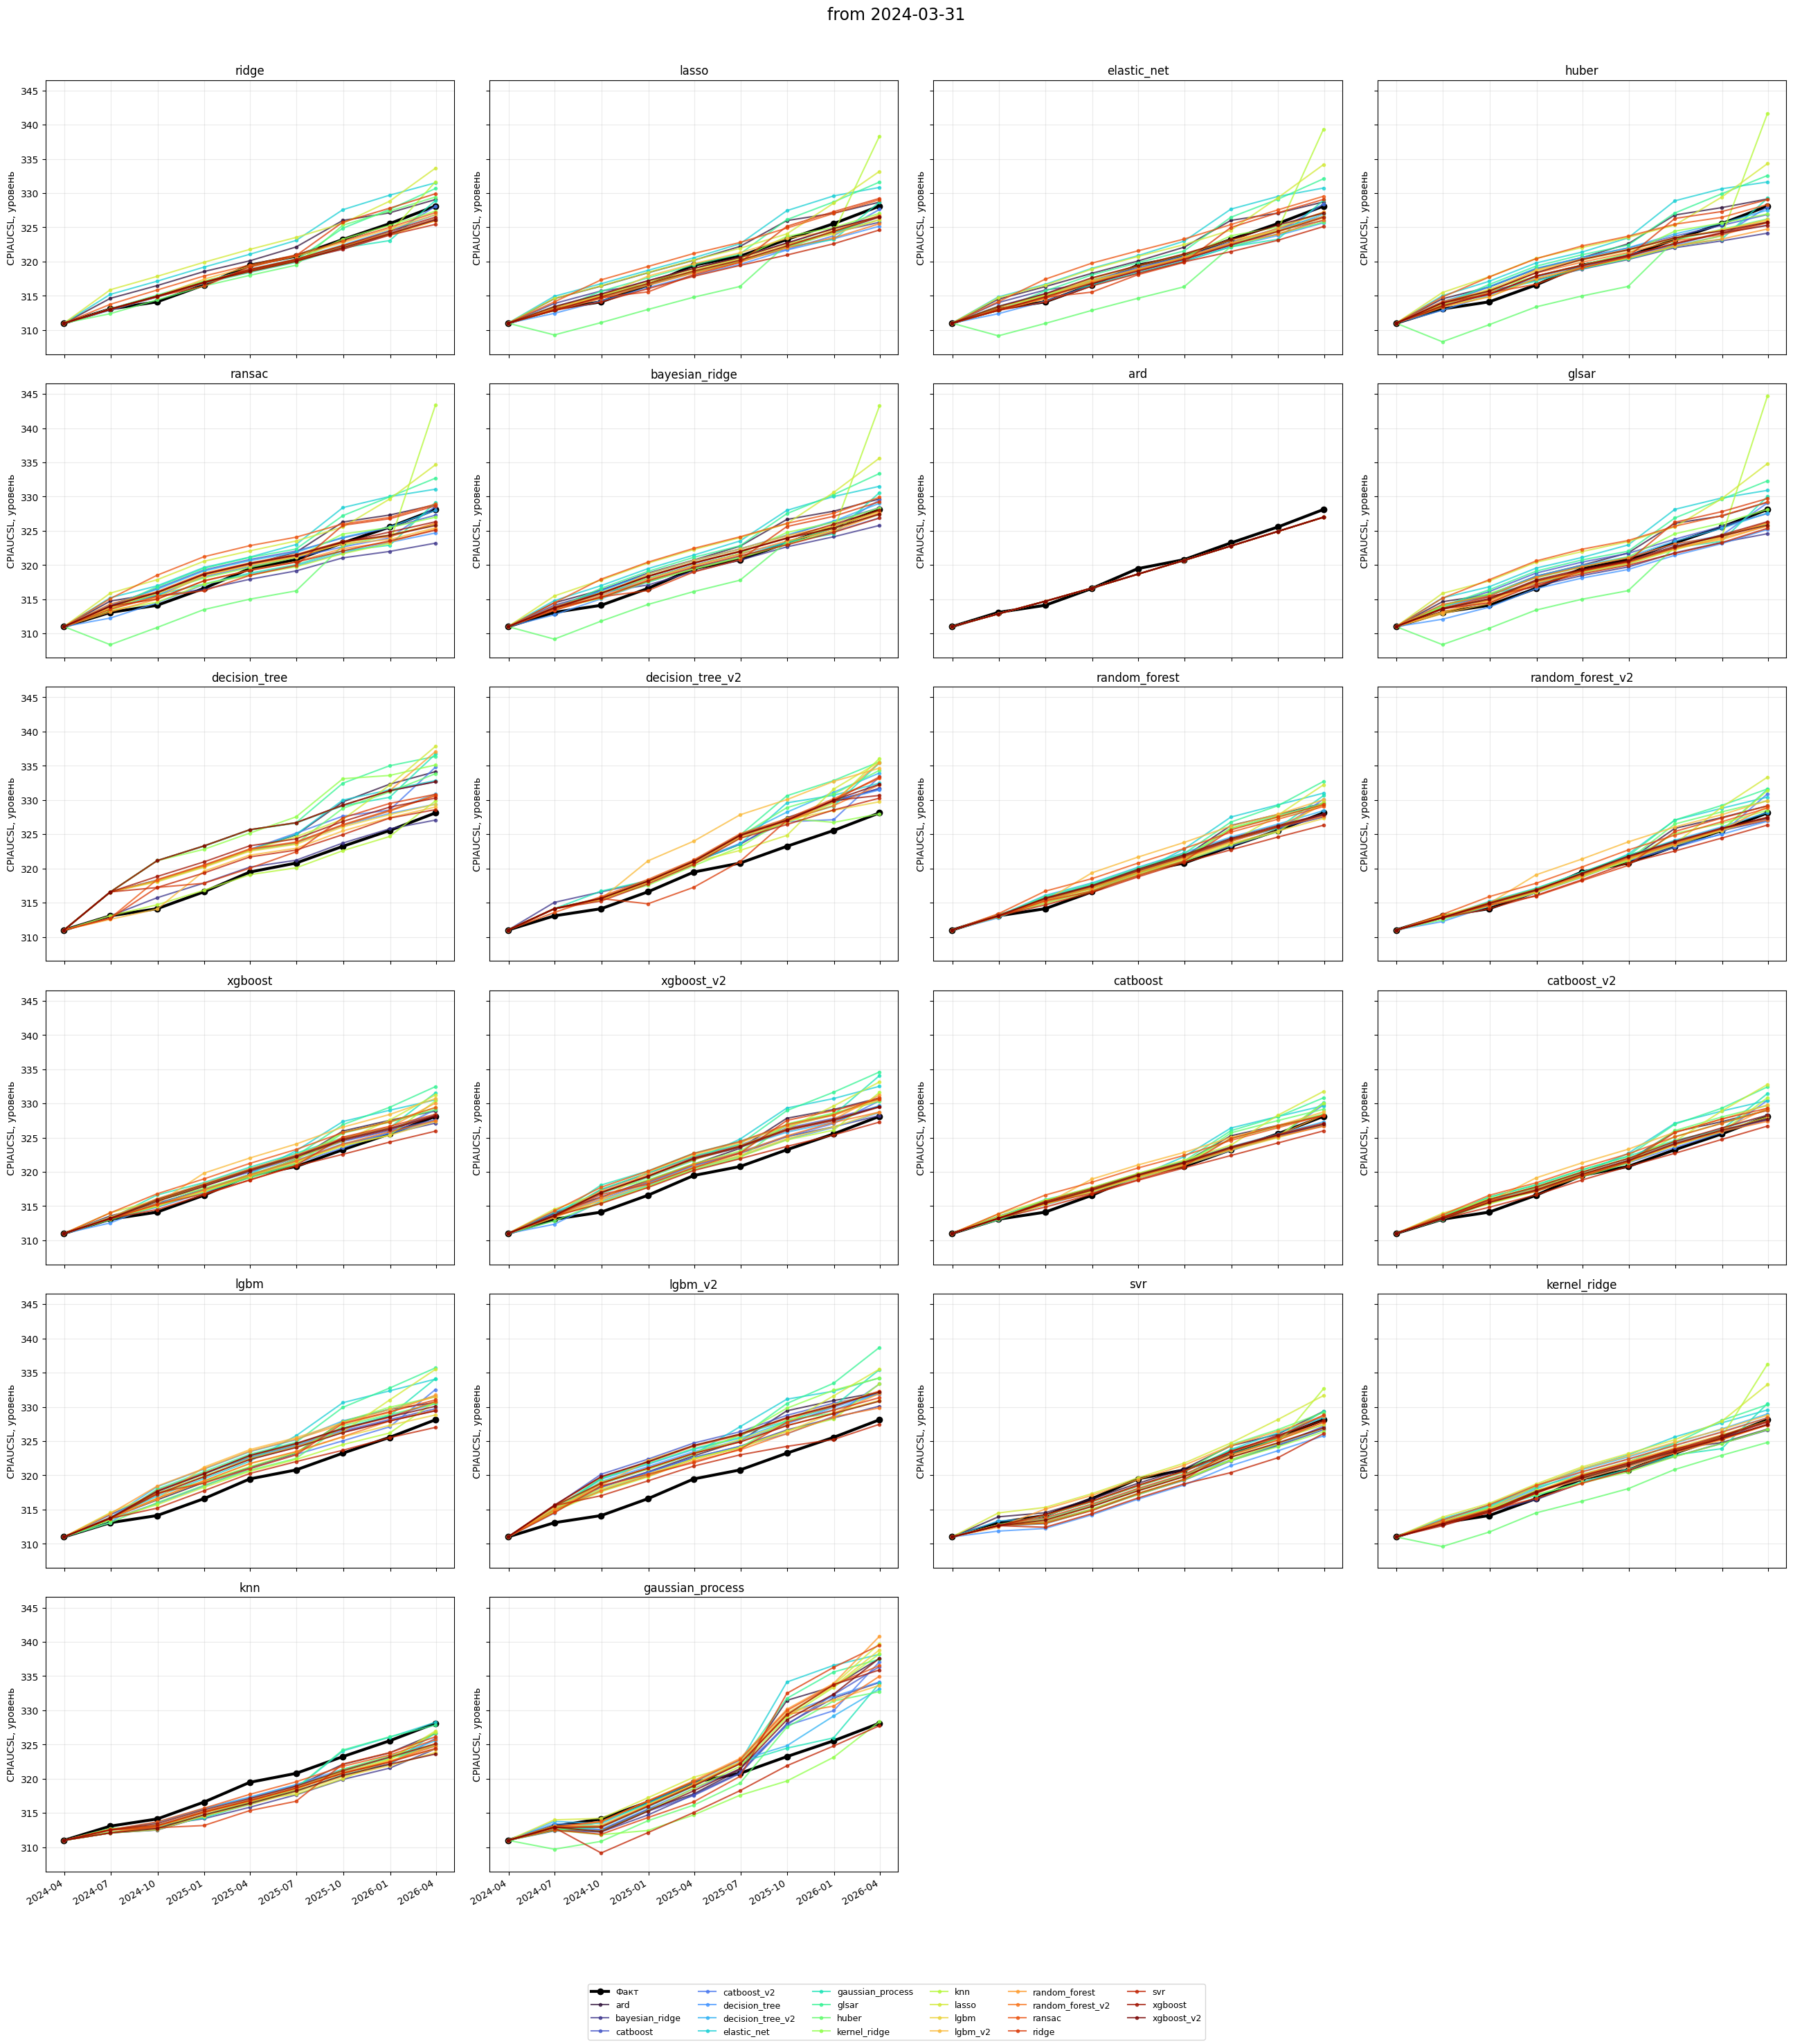

In [68]:
trajectory_predictions = oof_predictions[oof_predictions.origin.eq(train_end)].copy()
ncols, nrows = 4, int(np.ceil(len(INFL_MODEL_NAMES) / 4))
fig, axes = plt.subplots(nrows, ncols, figsize=(26, 5 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()
colors = plt.cm.turbo(np.linspace(0, 1, len(ACTIVE_RATE_NAMES)))
future_dates = data_full.index[data_full.index > train_end][:8]
actual_dates = [train_end, *future_dates]
actual_levels = cpi_level.loc[actual_dates]

for ax, model_name in zip(axes, INFL_MODEL_NAMES):
    ax.plot(actual_dates, actual_levels, color='black', marker='o', lw=3, label='Факт')
    subset = trajectory_predictions[trajectory_predictions.infl_model.eq(model_name)]
    for color, rate_name in zip(colors, ACTIVE_RATE_NAMES):
        line = subset[subset.rate_model.eq(rate_name)].sort_values('horizon')
        ax.plot([train_end, *line.Date], [cpi_level.loc[train_end], *line.level_pred],
                color=color, marker='o', ms=3, alpha=.75, label=rate_name)
    ax.set_title(model_name); ax.set_ylabel('CPIAUCSL, уровень'); ax.grid(alpha=.25)

for ax in axes[len(INFL_MODEL_NAMES):]: ax.axis('off')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=9)
fig.suptitle(f'from {train_end.date()}', fontsize=17)
fig.autofmt_xdate(); plt.tight_layout(rect=[0, .06, 1, .97])
fig.savefig(INFL_MODEL_DIR / 'inflation_trajectories.png', dpi=160, bbox_inches='tight')
plt.show()


In [69]:
print('Комбинаций траекторий:', len(ACTIVE_RATE_NAMES) * len(INFL_MODEL_NAMES))
print('Горизонтальных моделей:', 8 * len(ACTIVE_RATE_NAMES) * len(INFL_MODEL_NAMES))
print('PKL:', sum(model_path(model, rate, h).exists() for h in range(1, 9)
                  for rate in ACTIVE_RATE_NAMES for model in INFL_MODEL_NAMES))


Комбинаций траекторий: 484
Горизонтальных моделей: 3872
PKL: 3872
